# Validación del dataset preliminar

Este notebook verifica tres aspectos del dataset extraído con el spider `falabella`:

| # | Verificación | Sección |
|---|---|---|
| 1 | Porcentaje de valores faltantes por columna (límite: 10%) | Sección 2 |
| 2 | Filas duplicadas | Sección 3 |
| 3 | Mínimos y máximos de las variables numéricas | Sección 4 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("pandas:", pd.__version__)

pandas: 3.0.3


## 1. Carga del dataset

El CSV se genera desde la raíz del repositorio con:

```
scrapy crawl falabella -o falabella.csv
```

Se lee con `encoding="utf-8"` de forma explícita: si el archivo no estuviera en
esa codificación, esta celda fallaría con un `UnicodeDecodeError`.

In [2]:
CSV_PATH = "../data/falabella.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")


print(f"Archivo leído correctamente en UTF-8: {CSV_PATH}")
df.head()

Archivo leído correctamente en UTF-8: ../data/falabella.csv


,product,brand,category,seller,regular_price,special_price,has_cmr_discount
0,CELULAR GALAXY A57 5G,SAMSUNG,phones,FALABELLA,1999.0,1799.0,1
1,CELULAR GALAXY A37 5G,SAMSUNG,phones,FALABELLA,1799.0,1449.0,0
2,H600SMART 6+256GB SILVR+X7LITE,HONOR,phones,FALABELLA,1899.0,1499.0,0
3,MOTO G MAX 8+256 GRIS,MOTOROLA,phones,FALABELLA,1599.0,1199.0,1
4,IPHONE 16E 128GB,APPLE,phones,FALABELLA,4099.0,2299.0,1


## 2. Porcentaje de valores faltantes por columna

**Ninguna columna puede superar el 10% de nulos**.
Calculamos el conteo y el porcentaje para cada variable.

In [3]:
LIMITE_NULOS = 10.0

nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2),})

nulos["cumple"] = nulos["porcentaje"] <= LIMITE_NULOS
nulos = nulos.sort_values("porcentaje", ascending=False)

nulos

,nulos,porcentaje,cumple
regular_price,121,7.2,True
product,0,0.0,True
brand,0,0.0,True
category,0,0.0,True
seller,0,0.0,True
special_price,0,0.0,True
has_cmr_discount,0,0.0,True


In [4]:
columnas_fuera = nulos.index[~nulos["cumple"]].tolist()

if columnas_fuera:
    print(f"[FALLA] Columnas que superan el {LIMITE_NULOS}% de nulos: {columnas_fuera}")
else:
    print(f"[OK] Todas las columnas están por debajo del {LIMITE_NULOS}% de nulos.")
    print(f"     Máximo observado: {nulos['porcentaje'].max():.2f}% "
          f"({nulos['porcentaje'].idxmax()})")

[OK] Todas las columnas están por debajo del 10.0% de nulos.
     Máximo observado: 7.20% (regular_price)


### Gráfico de nulos por columna

Barras horizontales ordenadas de menor a mayor, con la línea del límite del 10%
como referencia. Cada barra lleva su valor etiquetado; al haber una sola serie
no necesitamos leyenda.

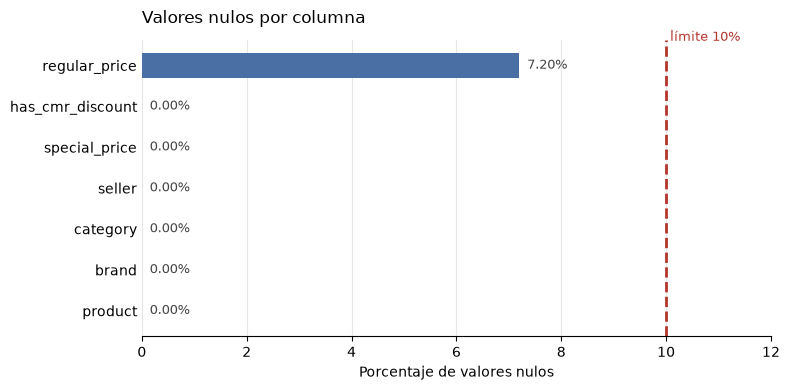

In [5]:
datos = nulos.sort_values("porcentaje")

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(datos.index, datos["porcentaje"], color="#4a6fa5", height=0.6)

# Línea de referencia del límite exigido
ax.axvline(LIMITE_NULOS, color="#b4352b", linewidth=2, linestyle="--")
ax.text(LIMITE_NULOS, len(datos) - 0.3, f" límite {LIMITE_NULOS:.0f}%",
        color="#b4352b", va="center", fontsize=9)

# Etiqueta directa al final de cada barra
for y, valor in enumerate(datos["porcentaje"]):
    ax.text(valor + 0.15, y, f"{valor:.2f}%", va="center", fontsize=9, color="#444444")

ax.set_xlim(0, max(LIMITE_NULOS + 2, datos["porcentaje"].max() * 1.35))
ax.set_xlabel("Porcentaje de valores nulos")
ax.set_title("Valores nulos por columna", loc="left", fontsize=12, pad=12)

# Ejes y grilla discretos
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Duplicados

Un mismo producto puede aparecer legítimamente más de una vez (por ejemplo, el
mismo modelo ofrecido por vendedores distintos), por lo que se revisan las filas
idénticas en todas las columnas.

In [6]:
dup_total = df.duplicated().sum()

print(f"Filas completamente duplicadas: {dup_total} ({dup_total / len(df) * 100:.2f}%)")

if dup_total:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Filas completamente duplicadas: 256 (15.24%)


,product,brand,category,seller,regular_price,special_price,has_cmr_discount
678,"15-FC0276LA RYZEN 7-7730U, 16GB RAM, 1TB SSD, ...",HP,laptops,MUNDO LAPTOP,4199.0,2999.0,0
701,"15-FC0276LA RYZEN 7-7730U, 16GB RAM, 1TB SSD, ...",HP,laptops,MUNDO LAPTOP,4199.0,2999.0,0
510,17T 5G 12RAM 512GB NUEVO COLOR - NEGRO,XIAOMI,phones,VAMTEL PERU,3000.0,2429.0,0
513,17T 5G 12RAM 512GB NUEVO COLOR - NEGRO,XIAOMI,phones,VAMTEL PERU,3000.0,2429.0,0
1133,"43"" NANO 4K UHD AI NU80 SMART TV 2026",LG,tvs,TOTTUS,1499.0,1099.0,1
1161,"43"" NANO 4K UHD AI NU80 SMART TV 2026",LG,tvs,TOTTUS,1499.0,1099.0,1
1176,"65"" OLED AI B6 4K SMART TV 2026",LG,tvs,LG TIENDA OFICIAL,6499.0,4299.0,0
1232,"65"" OLED AI B6 4K SMART TV 2026",LG,tvs,LG TIENDA OFICIAL,6499.0,4299.0,0
277,BMOBILE ORBIT 6+8GB + 128GB,GENERICO,phones,TECHNOWORLD.,560.0,409.0,0
354,BMOBILE ORBIT 6+8GB + 128GB,GENERICO,phones,TECHNOWORLD.,560.0,409.0,0


Las filas duplicadas se conservan sin modificar, dado que el dataset preliminar
corresponde al resultado directo del proceso de extracción. Su depuración se
realizará durante la etapa de análisis, posterior a esta entrega.

## 4. Mínimos y máximos de las variables numéricas

Rango de valores observado en `regular_price` y `special_price`, expresado en
soles (S/).

In [7]:
NUMERICAS = ["regular_price", "special_price"]

rangos = df[NUMERICAS].agg(["min", "max"]).T
rangos.columns = ["mínimo", "máximo"]

rangos

,mínimo,máximo
regular_price,19.90,49999.0
special_price,9.89,47999.0


In [8]:
for col in NUMERICAS:
    print(f"{col:<15} mínimo = S/ {df[col].min():>15,.2f}   "
          f"máximo = S/ {df[col].max():>15,.2f}")

regular_price   mínimo = S/           19.90   máximo = S/       49,999.00
special_price   mínimo = S/            9.89   máximo = S/       47,999.00
